/var/folders/lx/0h760fjj75g65qlknyyvp6y00000gp/T/ipykernel_15504/2044430630.py:12: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tavily = TavilySearchResults()


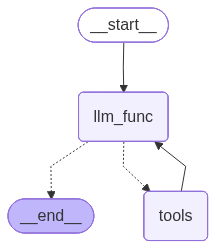

In [1]:
from langchain_community.tools import ArxivQueryRun,WikipediaQueryRun
from langchain_community.utilities import ArxivAPIWrapper,WikipediaAPIWrapper

api_arxiv_wrapper = ArxivAPIWrapper(top_k_results=2,doc_content_chars_max=500)
api_wiki_wrapper = WikipediaAPIWrapper(top_k_results=2,doc_content_chars_max=500)

arxiv = ArxivQueryRun(api_wrapper=api_arxiv_wrapper)
wiki = WikipediaQueryRun(api_wrapper=api_wiki_wrapper)

from langchain_community.tools.tavily_search import TavilySearchResults

tavily = TavilySearchResults()

def add(a:int,b:int)->int:
    """Docstring for add
    
    :param a: Description
    :type a: int
    :param b: Description
    :type b: int
    :return: Description
    :rtype: int"""

    return a+b

def mul(a:int,b:int)->int:
    """Docstring for mul
    
    :param a: Description
    :type a: int
    :param b: Description
    :type b: int
    :return: Description
    :rtype: int"""

    return a*b

def div(a:int,b:int)->int:
    """Docstring for div
    
    :param a: Description
    :type a: int
    :param b: Description
    :type b: int
    :return: Description
    :rtype: int"""

    return a/b


tools = [add,mul,div,tavily,arxiv,wiki]

from langchain_openai import ChatOpenAI

llm = ChatOpenAI(model="gpt-4o-mini")

llm_with_tools = llm.bind_tools(tools=tools)

from langgraph.graph import StateGraph,START,END
from typing import Annotated
from typing_extensions import TypedDict
from langgraph.graph.message import add_messages
from langchain_core.messages import HumanMessage,AIMessage,AnyMessage
from IPython.display import Image,display
from langgraph.prebuilt import ToolNode,tools_condition
from langgraph.checkpoint.memory import MemorySaver

class State(TypedDict):
    messages : Annotated[list[AnyMessage],add_messages]


def llm_func(state:State):
    return {"messages":[llm_with_tools.invoke(state['messages'])]}


builder = StateGraph(State)

builder.add_node('llm_func',llm_func)
builder.add_node('tools',ToolNode(tools))

builder.add_edge(START,'llm_func')
builder.add_conditional_edges('llm_func',###If the latest message (result) from assistant is a tool call->tool_condition routes to tools
                              # If the latest message (result) from assistant is not a tool call->tool_condition routes to END 
                              tools_condition)

builder.add_edge('tools','llm_func')

memory = MemorySaver()

graph_memory = builder.compile(memory)

display(Image(graph_memory.get_graph().draw_mermaid_png()))



In [2]:
messages = [HumanMessage(content="WHat is 2+2 and add the result to 5")]

config = {"configurable":{"thread_id":"1"}}

messages = graph_memory.invoke({"messages":messages},config=config)

for message in messages['messages']:
    message.pretty_print()

================================ Human Message =================================

WHat is 2+2 and add the result to 5
================================== Ai Message ==================================
Tool Calls:
  add (call_CMJVVTC5d4Mllgejh76xqkgY)
 Call ID: call_CMJVVTC5d4Mllgejh76xqkgY
  Args:
    a: 2
    b: 2
================================= Tool Message =================================
Name: add

4
================================== Ai Message ==================================
Tool Calls:
  add (call_R3Cd0zipac9LpyAYfLsZ6Xvp)
 Call ID: call_R3Cd0zipac9LpyAYfLsZ6Xvp
  Args:
    a: 4
    b: 5
================================= Tool Message =================================
Name: add

9
================================== Ai Message ==================================

The result of \(2 + 2\) is \(4\). Adding that to \(5\) gives a total of \(9\).
